In [1]:
# the following is added due to a warning
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from keras.utils import image_dataset_from_directory as LdImg
from keras.layers import Rescaling, RandomFlip, Resizing,Conv2D,MaxPooling2D,Flatten,Dense,Input
from keras.models import Sequential
from keras.saving import save_model
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

In [2]:
#the TrainData is an tf.data.Dataset. It has two fields, images and labels.
#images has dimension batch_size x image_size(0) x image_size(1) x channels) x 
# value of channesl is denpedent from the color_mode, e.g. rgb menas 3 channels
TrainData = LdImg("dataset/training_set", labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256))

Found 8000 files belonging to 2 classes.


In [3]:
print(TrainData.element_spec)


(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


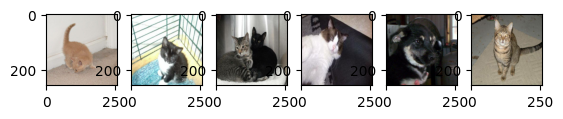

In [4]:
#plot TrainData to learn the struct of TrainData
figure=plt.figure()
for images, labels in TrainData.take(1):
    i = int(1)
    for image in images:
        plt.subplot(1,6,i)
        plt.imshow(image.numpy().astype("uint8"))
        i += 1
        if i > 6:
            break
        
        

In [5]:
PreProcessing = Sequential([
    Rescaling(1./255),
    Resizing(50,50)
])
PreProcessing.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resizing (Resizing)                  │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
TrainDataPreProcd = TrainData.map(lambda images, labels: (PreProcessing(images),labels))
print(len(list(TrainDataPreProcd)))

250


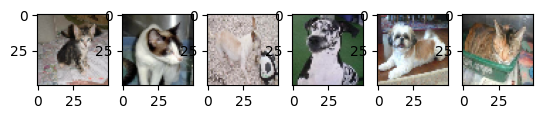

In [7]:
figure=plt.figure()
for images, labels in TrainDataPreProcd.take(1):
    i = int(1)
    for image in images:
        plt.subplot(1,6,i)
        plt.imshow((image.numpy()*255).astype("uint8"))
        i += 1
        if i > 6:
            break
plt.show()  

In [39]:
#create the cnn model
CNNModel = Sequential()
# Define the input shape instead specify it direction in the first convolution layer
CNNModel.add(Input(shape=(50, 50, 3))) 
#add convolution layer
CNNModel.add(Conv2D(32,(3,3),activation='relu'))
#add pooling layer
CNNModel.add(MaxPooling2D(pool_size=(2,2)))
#add another convolution layer
CNNModel.add(Conv2D(32,(3,3),activation='relu'))
CNNModel.add(MaxPooling2D(pool_size=(2,2)))
#add flatten layer
CNNModel.add(Flatten())
#add fullly connected layer
CNNModel.add(Dense(units=128,activation='relu'))
CNNModel.add(Dense(units=1,activation='sigmoid'))


In [40]:
#configure the cnn model
CNNModel.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [41]:
CNNModel.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 48, 48, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 22, 22, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 11, 11, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 3872)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         495,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 506,017 (1.93 MB)

 Trainable params: 506,017 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
#train the model
CNNModel.fit(TrainDataPreProcd,epochs=25)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.5354 - loss: 0.7044
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.6888 - loss: 0.5892
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.7378 - loss: 0.5193
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7765 - loss: 0.4674
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.8024 - loss: 0.4319
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.8278 - loss: 0.3935
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.8445 - loss: 0.3567
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.8649 - loss: 0.3093
Epoch 9/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.8890 - loss: 0.2600
Epoch 10/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9119 - loss: 0.2127
Epoch 11/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.9289 - loss: 0.1734
Epoch 12/25
250/250 ━━━━━━━━━━

In [43]:
EvaResults = CNNModel.predict(TrainDataPreProcd)
print(EvaResults)

250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step
[[9.9999970e-01]
 [9.9854988e-01]
 [9.9438286e-01]
 ...
 [4.1128056e-05]
 [3.6886611e-04]
 [1.3274269e-09]]


In [44]:
print(EvaResults.shape)

(8000, 1)


In [45]:
TrainResults = (EvaResults>0.5).astype(int)
ExpectedLabel = []
for images, labels in TrainDataPreProcd:
    for label in labels:
        ExpectedLabel.append(label.numpy())

ExpectedLabel = np.array(ExpectedLabel).reshape(-1, 1)


In [46]:
print(ExpectedLabel.shape)

(8000, 1)


In [47]:
AccuracyScore = accuracy_score(ExpectedLabel,TrainResults)
print(AccuracyScore)

0.49625


In [48]:
CNNModel.save("CNNModel_50per.keras")